# AI & Labor Market: Automation Risk Analysis
## Exploratory Data Analysis — Anthropic Economic Index
**Dataset:** Anthropic Economic Index (Hugging Face, February 2025 release)  
**Author:** Daryna Akkus  
**Goal:** Understand which occupations face the highest automation risk and why.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visual style
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print("Libraries loaded successfully ✓")

Libraries loaded successfully ✓


## 1. Loading the Data

In [20]:
# If using Google Colab — upload the file manually:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('wage_data.csv')

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns:\n{list(df.columns)}")

Shape: 1090 rows × 10 columns

Columns:
['SOCcode', 'JobName', 'JobFamily', 'isBright', 'isGreen', 'JobZone', 'MedianSalary', 'JobForecast', 'ChanceAuto', 'WageGroup']


## 2. First Look at the Data

In [21]:
df.head(10)


,SOCcode,JobName,JobFamily,isBright,isGreen,JobZone,MedianSalary,JobForecast,ChanceAuto,WageGroup
0,13-2011.01,Accountants,Business and Financial Operations,True,False,4,70500.00,146000,-1.0,Accountants and Auditors
1,13-2011.00,Accountants and Auditors,Business and Financial Operations,True,False,-1,70500.00,146000,94.0,NaN
2,27-2011.00,Actors,"Arts, Design, Entertainment, Sports, and Media",False,False,2,17.54,7700,37.0,NaN
3,15-2011.00,Actuaries,Computer and Mathematical,True,False,4,102880.00,2200,21.0,NaN
4,29-1199.01,Acupuncturists,Healthcare Practitioners and Technical,True,False,5,73960.00,3400,-1.0,"Health Diagnosing and Treating Practitioners, ..."
5,29-1141.01,Acute Care Nurses,Healthcare Practitioners and Technical,True,False,3,71730.00,210400,-1.0,Registered Nurses
6,25-2059.01,Adapted Physical Education Specialists,"Education, Training, and Library",True,False,4,56680.00,3200,-1.0,"Special Education Teachers, All Other"
7,51-9191.00,Adhesive Bonding Machine Operators and Tenders,Production,False,False,2,33820.00,2100,95.0,NaN
8,23-1021.00,"Administrative Law Judges, Adjudicators, and H...",Legal,False,False,5,99850.00,800,64.0,NaN
9,11-3011.00,Administrative Services Managers,Management,True,False,3,96180.00,28100,73.0,NaN


In [22]:
df.describe(include='all').round(2)

,SOCcode,JobName,JobFamily,isBright,isGreen,JobZone,MedianSalary,JobForecast,ChanceAuto,WageGroup
count,1090,1090,1090,1090,1090,1090.00,1090.00,1090.00,1090.00,295
unique,1090,1090,22,2,2,NaN,NaN,NaN,NaN,117
top,19-1023.00,Zoologists and Wildlife Biologists,Production,False,False,NaN,NaN,NaN,NaN,"Physicians and Surgeons, All Other"
freq,1,1,122,655,886,NaN,NaN,NaN,NaN,12
mean,NaN,NaN,NaN,NaN,NaN,2.73,60103.36,26981.19,31.93,NaN
std,NaN,NaN,NaN,NaN,NaN,1.71,33138.87,62739.09,39.00,NaN
min,NaN,NaN,NaN,NaN,NaN,-1.00,15.94,0.00,-1.00,NaN
25%,NaN,NaN,NaN,NaN,NaN,2.00,37877.50,2400.00,-1.00,NaN
50%,NaN,NaN,NaN,NaN,NaN,3.00,53300.00,7700.00,4.00,NaN
75%,NaN,NaN,NaN,NaN,NaN,4.00,72517.50,21300.00,74.75,NaN


## 3. Data Quality Check

In [23]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

if missing_df.empty:
    print("No missing values found ✓")
else:
    print(missing_df)

print(f"\n=== Data Types ===")
print(df.dtypes)

print(f"\n=== ChanceAuto special values ===")
print(f"Rows with ChanceAuto = -1.0: {(df['ChanceAuto'] == -1.0).sum()}")
print(f"Rows with valid ChanceAuto (0–100): {((df['ChanceAuto'] >= 0) & (df['ChanceAuto'] <= 100)).sum()}")

=== Missing Values ===
           Missing Count  Missing %
WageGroup            795       72.9

=== Data Types ===
SOCcode          object
JobName          object
JobFamily        object
isBright           bool
isGreen            bool
JobZone           int64
MedianSalary    float64
JobForecast       int64
ChanceAuto      float64
WageGroup        object
dtype: object

=== ChanceAuto special values ===
Rows with ChanceAuto = -1.0: 424
Rows with valid ChanceAuto (0–100): 666


## 4. Cleaning: Remove Invalid ChanceAuto Values
*Note: -1.0 values indicate missing automation score in the original dataset.*

In [24]:
df_clean = df[df['ChanceAuto'] >= 0].copy()

print(f"Original dataset:  {len(df)} rows")
print(f"After cleaning:    {len(df_clean)} rows")
print(f"Removed:           {len(df) - len(df_clean)} rows (no automation score)")

Original dataset:  1090 rows
After cleaning:    666 rows
Removed:           424 rows (no automation score)


## 5. Job Families Overview

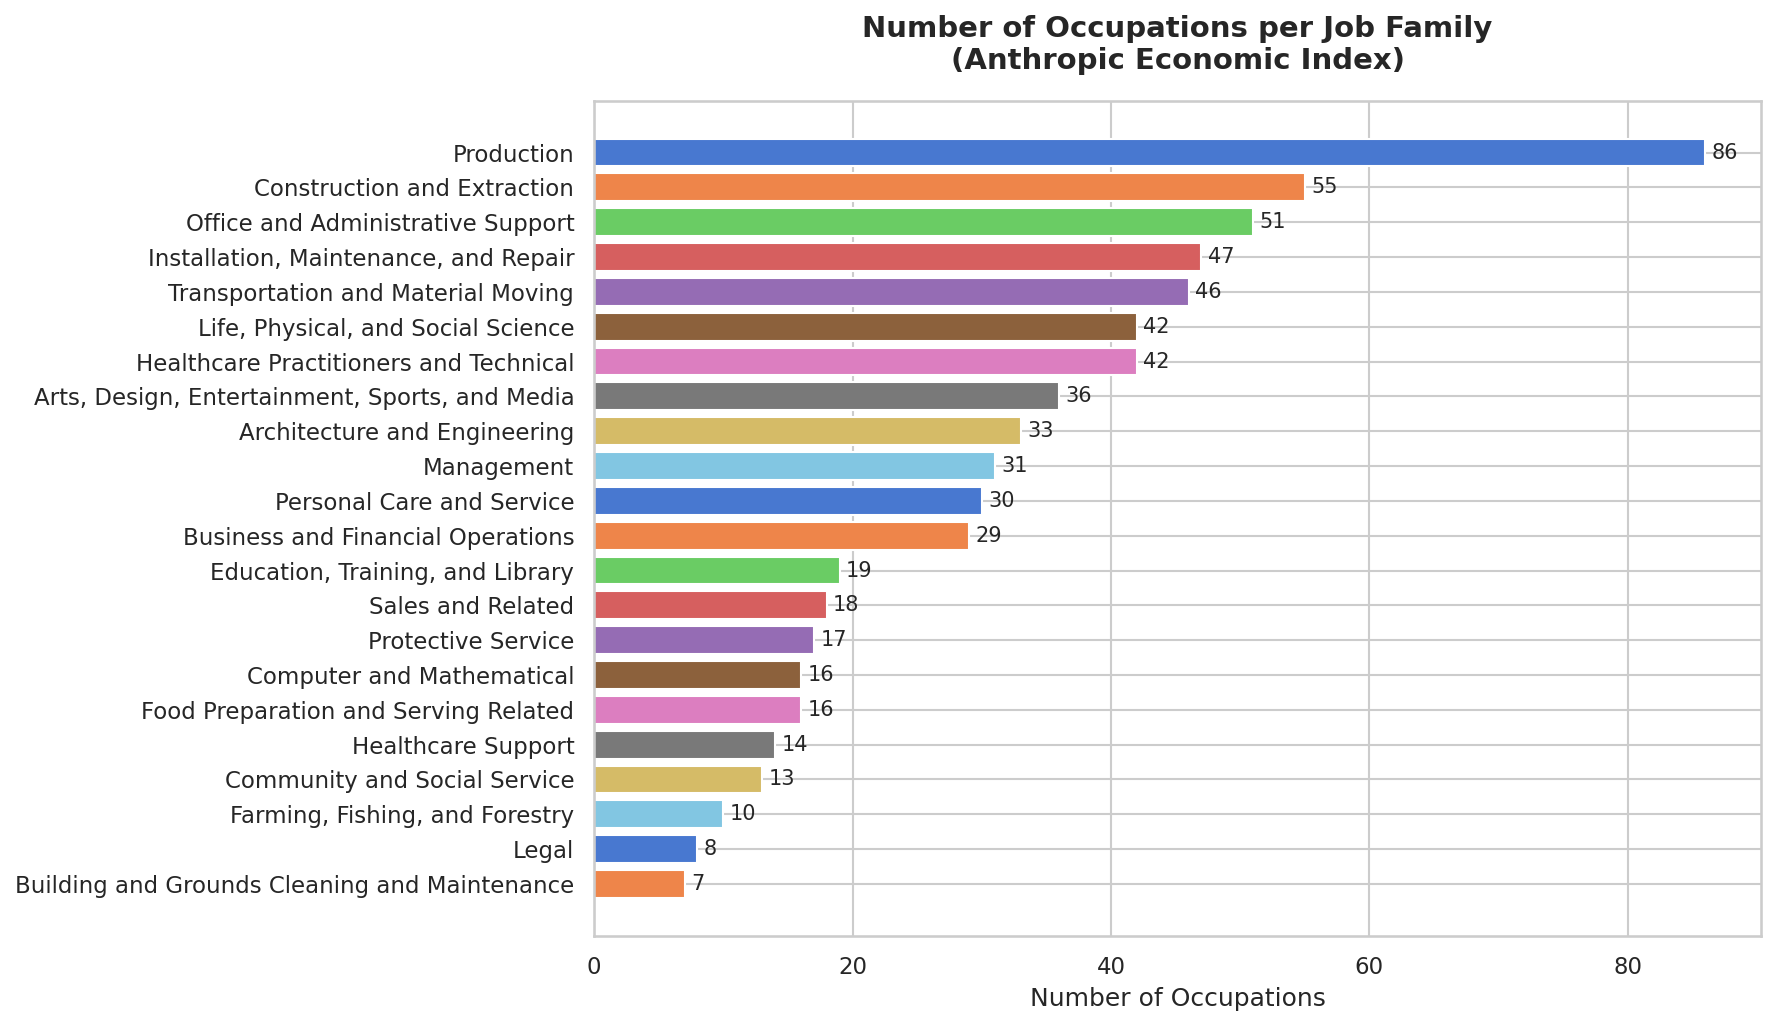

Saved: images/fig1_job_families.png


In [25]:
import os

family_counts = df_clean['JobFamily'].value_counts()

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(family_counts.index, family_counts.values,
               color=sns.color_palette('muted', len(family_counts)))
ax.set_xlabel('Number of Occupations', fontsize=12)
ax.set_title('Number of Occupations per Job Family\n(Anthropic Economic Index)',
             fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()

for bar, val in zip(bars, family_counts.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

plt.tight_layout()

# Create the 'images' directory if it doesn't exist
os.makedirs('images', exist_ok=True)

plt.savefig('images/fig1_job_families.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/fig1_job_families.png")

## 6. Automation Risk Distribution
*ChanceAuto: probability (0–100%) that a given occupation can be automated by AI.*

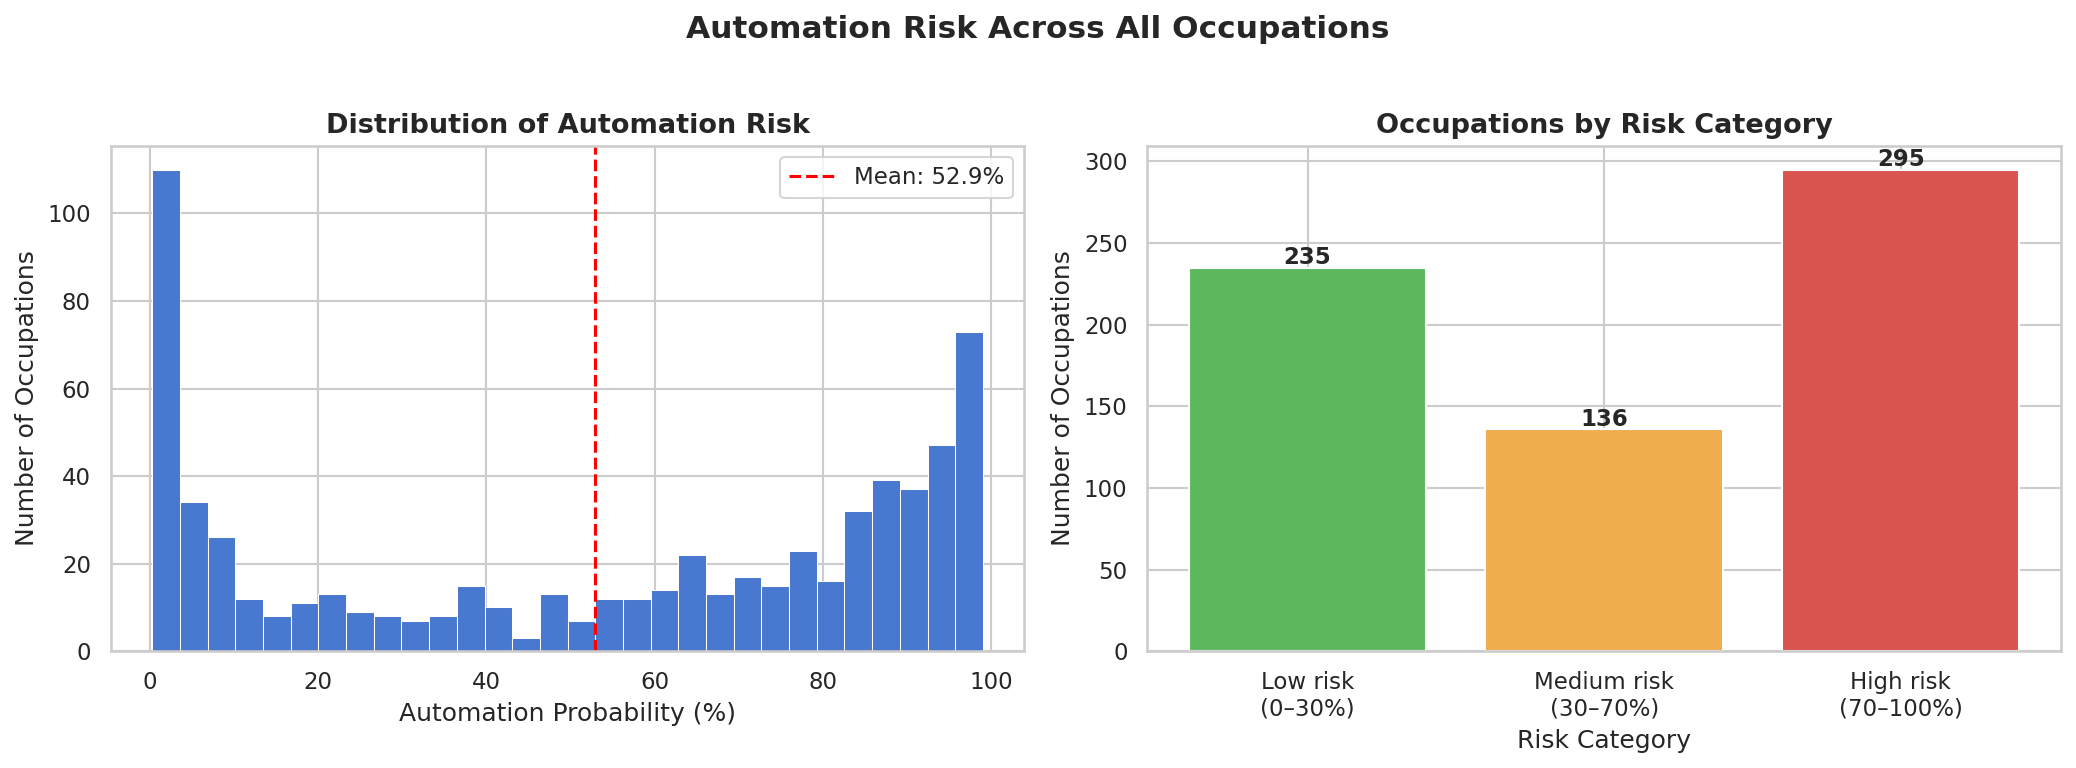

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['ChanceAuto'], bins=30,
             color='#4878CF', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution of Automation Risk', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Automation Probability (%)')
axes[0].set_ylabel('Number of Occupations')
axes[0].axvline(df_clean['ChanceAuto'].mean(), color='red',
                linestyle='--', linewidth=1.5, label=f"Mean: {df_clean['ChanceAuto'].mean():.1f}%")
axes[0].legend()

# Risk categories
bins = [0, 30, 70, 100]
labels = ['Low risk\n(0–30%)', 'Medium risk\n(30–70%)', 'High risk\n(70–100%)']
df_clean['RiskCategory'] = pd.cut(df_clean['ChanceAuto'], bins=bins, labels=labels)
risk_counts = df_clean['RiskCategory'].value_counts().reindex(labels)

colors = ['#5cb85c', '#f0ad4e', '#d9534f']
axes[1].bar(risk_counts.index, risk_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Occupations by Risk Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Risk Category')
axes[1].set_ylabel('Number of Occupations')
for i, (idx, val) in enumerate(risk_counts.items()):
    axes[1].text(i, val + 2, str(val), ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Automation Risk Across All Occupations',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/fig2_automation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Top 15 Most At-Risk Occupations

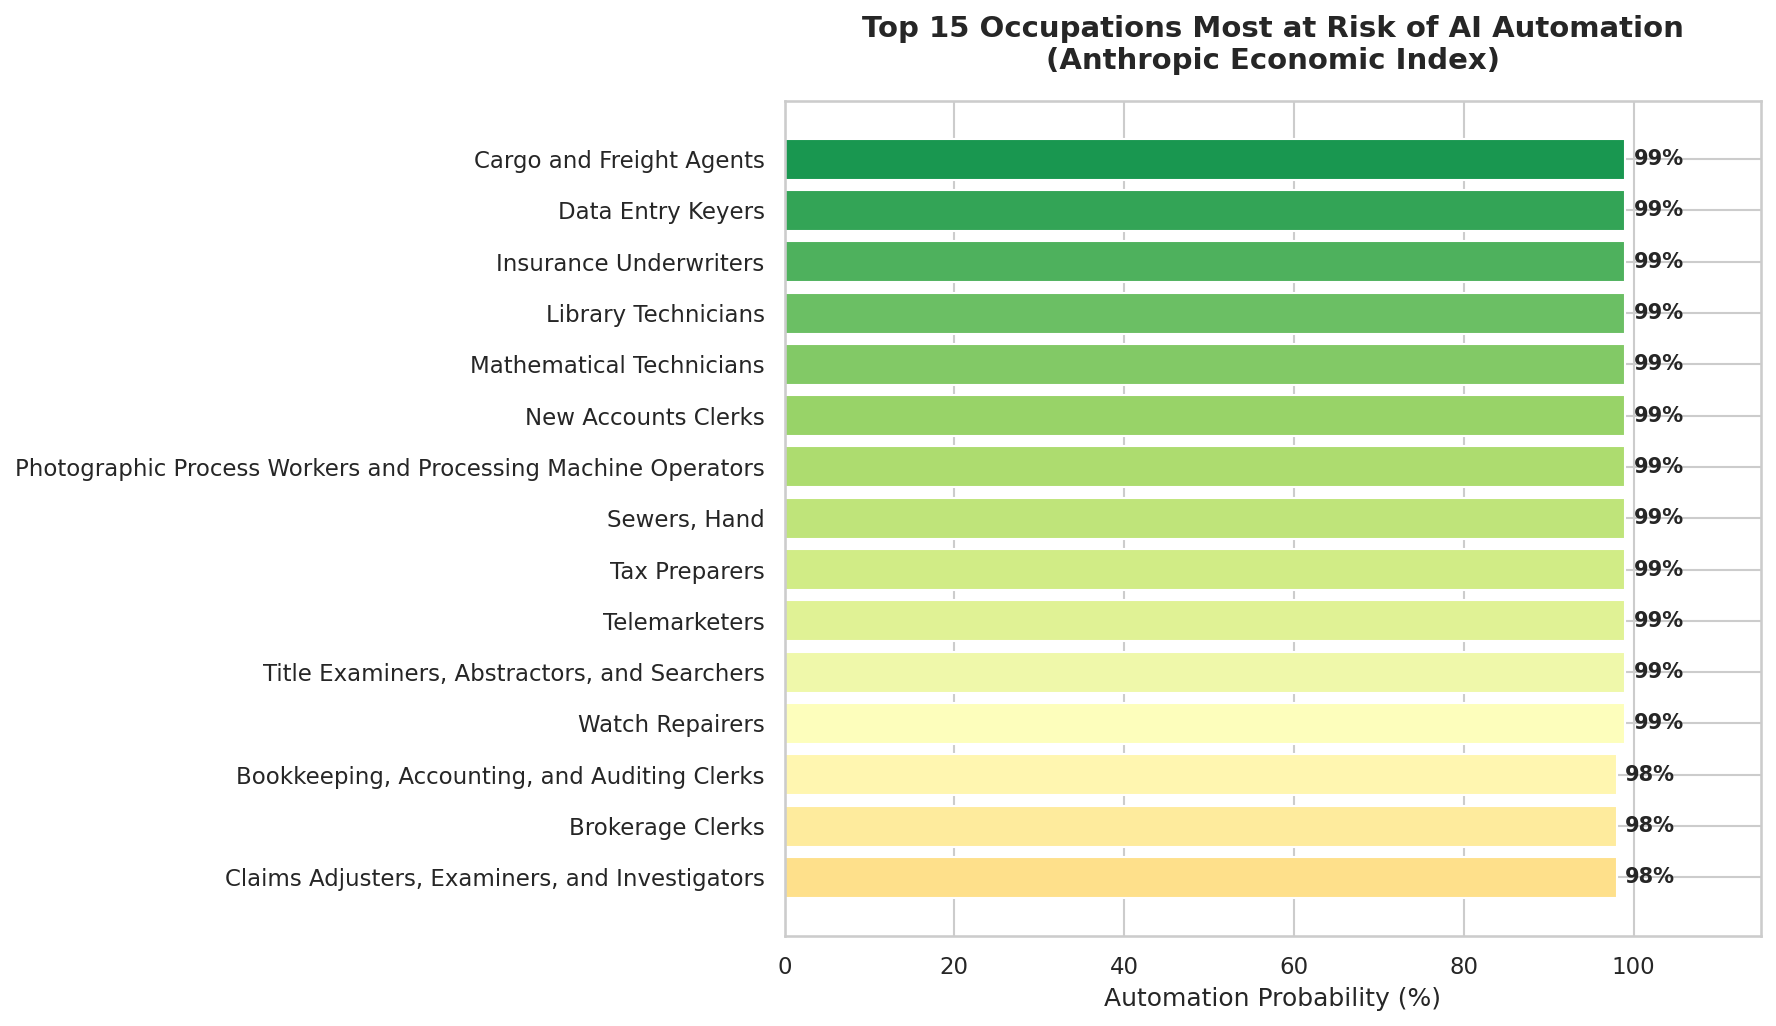

                                                      JobName                             JobFamily  ChanceAuto  MedianSalary
                                     Cargo and Freight Agents     Office and Administrative Support        99.0       43210.0
                                            Data Entry Keyers     Office and Administrative Support        99.0       32170.0
                                       Insurance Underwriters     Business and Financial Operations        99.0       69380.0
                                          Library Technicians      Education, Training, and Library        99.0       34040.0
                                     Mathematical Technicians             Computer and Mathematical        99.0       57190.0
                                          New Accounts Clerks     Office and Administrative Support        99.0       35800.0
Photographic Process Workers and Processing Machine Operators                            Production        99.0       

In [27]:
top15 = df_clean.nlargest(15, 'ChanceAuto')[['JobName', 'JobFamily', 'ChanceAuto', 'MedianSalary']]

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.6, 15))
bars = ax.barh(top15['JobName'], top15['ChanceAuto'], color=colors)

ax.set_xlabel('Automation Probability (%)', fontsize=12)
ax.set_title('Top 15 Occupations Most at Risk of AI Automation\n(Anthropic Economic Index)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 115)
ax.invert_yaxis()

for bar, val in zip(bars, top15['ChanceAuto']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('images/fig3_top15_at_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print(top15.to_string(index=False))

## 8. Key Statistics Summary

In [28]:
high_risk = df_clean[df_clean['ChanceAuto'] >= 70]
low_risk  = df_clean[df_clean['ChanceAuto'] <= 30]

print("=" * 50)
print("KEY FINDINGS — Anthropic Economic Index")
print("=" * 50)
print(f"Total occupations analyzed:       {len(df_clean)}")
print(f"Average automation risk:          {df_clean['ChanceAuto'].mean():.1f}%")
print(f"Median automation risk:           {df_clean['ChanceAuto'].median():.1f}%")
print()
print(f"HIGH RISK occupations (>70%):     {len(high_risk)} ({len(high_risk)/len(df_clean)*100:.1f}%)")
print(f"LOW RISK occupations (<30%):      {len(low_risk)} ({len(low_risk)/len(df_clean)*100:.1f}%)")
print()
print(f"Avg salary — high risk jobs:      ${high_risk['MedianSalary'].mean():,.0f}")
print(f"Avg salary — low risk jobs:       ${low_risk['MedianSalary'].mean():,.0f}")

KEY FINDINGS — Anthropic Economic Index
Total occupations analyzed:       666
Average automation risk:          52.9%
Median automation risk:           63.0%

HIGH RISK occupations (>70%):     299 (44.9%)
LOW RISK occupations (<30%):      235 (35.3%)

Avg salary — high risk jobs:      $40,986
Avg salary — low risk jobs:       $72,110
